In [1]:
# ! pip install -U -q open-deep-research

In [1]:
# import open_deep_research  
from src import open_deep_research 
print(open_deep_research.__version__) 

0.0.10


In [2]:
from IPython.display import Image, display
from langgraph.types import Command
from langgraph.checkpoint.memory import MemorySaver
from open_deep_research.graph import builder

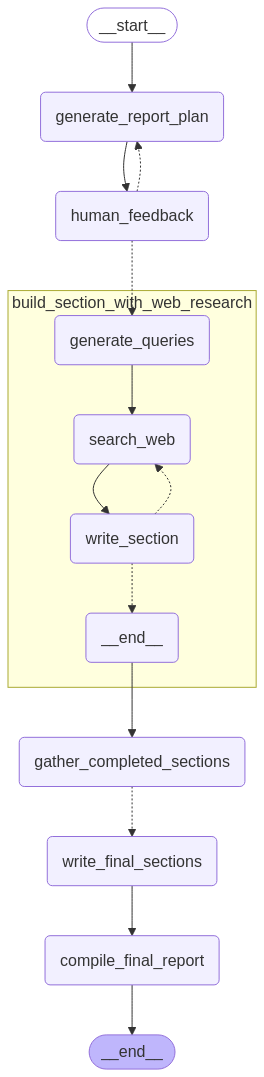

In [3]:
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [4]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("TAVILY_API_KEY")
_set_env("GOOGLE_API_KEY")


In [5]:
!pip install -U langchain-google-genai


[notice] A new release of pip available: 22.3 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import uuid 
from IPython.display import Markdown

# Claude 3.7 Sonnet for planning with perplexity search
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "perplexity",
#                            "planner_provider": "anthropic",
#                            "planner_model": "claude-3-7-sonnet-latest",
#                            "writer_provider": "anthropic",
#                            "writer_model": "claude-3-5-sonnet-latest",
#                            "max_search_depth": 2,
#                            "report_structure": REPORT_STRUCTURE,
#                            }}

# DeepSeek-R1-Distill-Llama-70B for planning and llama-3.3-70b-versatile for writing
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "tavily",
#                            "planner_provider": "groq",
#                            "planner_model": "deepseek-r1-distill-llama-70b",
#                            "writer_provider": "groq",
#                            "writer_model": "llama-3.3-70b-versatile",
#                            "report_structure": REPORT_STRUCTURE,
#                            "max_search_depth": 1,}
#                            }

thread = {"configurable": {"thread_id": str(uuid.uuid4()),
                           "search_api": "tavily",
                           "planner_provider": "google_genai",
                           "planner_model": "gemini-2.5-pro-exp-03-25",
                           "writer_provider": "google_genai",
                           "writer_model": "gemini-2.5-pro-exp-03-25",
                           "max_search_depth": 3,
                           "number_of_queries": 5,}
                           }

# Fast config (less search depth) with o3-mini for planning and Claude 3.5 Sonnet for writing
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "tavily",
#                            "planner_provider": "openai",
#                            "planner_model": "o3-mini",
#                            "writer_provider": "anthropic",
#                            "writer_model": "claude-3-5-sonnet-latest",
#                            "max_search_depth": 1,
#                            "report_structure": REPORT_STRUCTURE,
#                            }}

# Create a topic
# topic = "Use of tranformer models and LLM encoders as vector transformers for sentiment analysis of resource poor languages such as sanskrit and punjabi"

topic = "can you explain about 1 bit model "

# Run the graph until the interruption
async for event in graph.astream({"topic":topic,}, thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

Please provide feedback on the following report plan. 
                        

Section: Introduction
Description: Provide a brief overview of the increasing complexity of Large Language Models (LLMs) and the associated computational costs. Introduce model quantization as a strategy to mitigate these costs, setting the stage for 1-bit models as an extreme and promising approach. Highlight the relevance of 1-bit models for efficiency, cost reduction, and enabling AI on resource-constrained devices.
Research needed: No


Section: Fundamentals of Model Quantization
Description: Explain the fundamental concept of model quantization in neural networks, detailing how it reduces the precision of model parameters (weights) and activations from standard floating-point formats (e.g., 32-bit) to lower bit representations. Discuss the primary motivations: reducing memory footprint, accelerating computation, and lowering energy consumption. Briefly introduce different quantization levels (e.g., 8-bit, 4-bit) leading down to 1-bit.
Research needed: Yes


Section: Defining 1-bit Models
Description: Define what constitutes a 1-bit model, focusing on the representation of weights using only two values (e.g., +1, -1) or three values for ternary variants like 1.58-bit models (e.g., -1, 0, +1). Discuss how activations might also be quantized. Trace the historical context briefly, mentioning early work on Binary Neural Networks (BNNs) and quantization in models like BERT, leading to the recent focus on 1-bit LLMs.
Research needed: Yes


Section: BitNet and the 1.58-bit Architecture
Description: Deep dive into BitNet, a significant architecture enabling 1-bit Transformers for LLMs. Explain its core components and how it differs from traditional Transformer architectures. Specifically detail the BitNet b1.58 variant, which uses ternary {-1, 0, 1} weights, and its significance as highlighted in recent research (e.g., 'The Era of 1-bit LLMs').
Research needed: Yes


Section: Training Methodologies for 1-bit LLMs
Description: Explore the specific techniques and challenges involved in training 1-bit LLMs. Discuss methods like using full-precision copies of weights for gradient updates while using quantized values in forward/backward passes, Quantization-Aware Training (QAT), and specialized training recipes or optimizers developed for these models. Contrast these with training standard full-precision models.
Research needed: Yes


Section: Efficiency Gains: Memory, Speed, and Energy
Description: Quantify the advantages of 1-bit models. Detail the substantial reductions in memory usage (model size) and energy consumption compared to traditional FP16/BF16 or even 8-bit models. Discuss the potential for significant speed-ups in inference due to the replacement of matrix multiplications with simpler bit-wise operations. Reference performance benchmarks where available (e.g., comparing BitNet variants against standard baselines on language modeling tasks).
Research needed: Yes


Section: Challenges and Performance Considerations
Description: Address the inherent trade-offs and difficulties associated with extreme quantization. Discuss the potential impact on model accuracy and performance, especially for tasks requiring high precision or nuanced understanding. Cover challenges in the training process, such as stability and convergence. Mention the ongoing research into whether 1-bit models adhere to the same scaling laws as their full-precision counterparts.
Research needed: Yes


Section: Applications and Future Directions
Description: Discuss the primary application areas where 1-bit models offer significant advantages, particularly in resource-constrained environments like edge devices (smartphones, IoT) and mobile platforms. Explore the potential impact on democratizing access to powerful LLMs. Discuss future research directions, including the development of hardware specifically optimized for 1-bit computations and further improvements in training techniques and model performance.
Research needed: Yes


Section: Conclusion
Description: Recap the core concepts of 1-bit LLMs, emphasizing their definition, key architectures like BitNet b1.58, and the primary motivation (efficiency). Summarize the major advantages (memory, speed, energy) and the challenges (performance trade-offs, training complexity). Include a structured element, like a bulleted list or simple table, comparing the pros and cons. Conclude with a concise statement on the potential significance of 1-bit models in the evolving landscape of AI.
Research needed: No


                        
Does the report plan meet your needs?
Pass 'true' to approve the report plan.
Or, provide feedback to regenerate the report plan:

In [78]:
# Pass feedback to update the report plan  
async for event in graph.astream(Command(resume="add information about whether we can input some data that was never seen by the enocder and then do its sentiment analysis somehow"), thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

Please provide feedback on the following report plan. 
                        

Section: Introduction
Description: Briefly introduce sentiment analysis, transformer models, LLMs, vector embeddings, and the challenge of applying these to low-resource languages like Sanskrit and Punjabi. State the report's purpose.
Research needed: No


Section: Transformer Encoders and Vector Embeddings
Description: Explain the architecture of transformer encoders (attention, tokenization, embeddings). Describe how encoders generate vector representations (embeddings) that capture semantic meaning, suitable for downstream tasks like sentiment analysis.
Research needed: Yes


Section: Sentiment Analysis Challenges in Low-Resource Languages
Description: Define low-resource languages and outline the specific challenges (data scarcity, lack of annotated datasets, limited tooling) for performing sentiment analysis in Sanskrit and Punjabi.
Research needed: Yes


Section: Leveraging Transformers for Low-Resource Sentiment Analysis
Description: Discuss strategies for using transformer encoders for sentiment analysis in Sanskrit and Punjabi. Cover transfer learning from high-resource or multilingual models, fine-tuning on available data, and the role of vector embeddings. Address how these models might handle previously unseen text for sentiment analysis (zero-shot/few-shot capabilities). Mention relevant tools/libraries like Hugging Face.
Research needed: Yes


Section: Conclusion
Description: Summarize the key findings. Include a table or list distilling the main points (e.g., challenges vs. solutions, model types). Reiterate the potential of transformer-based vector embeddings for sentiment analysis in low-resource languages.
Research needed: No


                        
Does the report plan meet your needs?
Pass 'true' to approve the report plan.
Or, provide feedback to regenerate the report plan:

In [7]:
# Pass True to approve the report plan 
async for event in graph.astream(Command(resume=True), thread, stream_mode="updates"):
    print(event)
    print("\n")

{'human_feedback': None}


{'build_section_with_web_research': {'completed_sections': [Section(name='Applications and Future Directions', description='Discuss the primary application areas where 1-bit models offer significant advantages, particularly in resource-constrained environments like edge devices (smartphones, IoT) and mobile platforms. Explore the potential impact on democratizing access to powerful LLMs. Discuss future research directions, including the development of hardware specifically optimized for 1-bit computations and further improvements in training techniques and model performance.', research=True, content="## Applications and Future Directions\n\nThe primary advantage of 1-bit Large Language Models (LLMs) lies in their dramatically reduced computational and memory requirements, making them exceptionally suitable for deployment in resource-constrained environments [6, 8, 18]. This opens up significant possibilities for running powerful AI capabilities directly on ed

In [8]:
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

# Can you explain about 1 bit model

Large Language Models (LLMs) have demonstrated remarkable capabilities, but their increasing size and complexity come with significant computational demands. Training and deploying these massive models often require substantial memory, processing power, and energy, translating into high operational costs and limiting their accessibility [1, 2, 3, 4]. These resource requirements pose a major bottleneck, particularly for applications outside of large data centers.

To address these challenges, model quantization has emerged as a vital optimization strategy [1]. Quantization reduces the numerical precision used to represent a model's parameters (weights) and sometimes activations, converting them from standard 32-bit floating-point numbers to lower-bit formats like 8-bit or 4-bit integers [1, 5, 6]. This process significantly shrinks the model's memory footprint, accelerates computation speed, and reduces energy consumption [2, 3, 4].

This report focuses on an extreme and increasingly promising form of this technique: 1-bit models. These models push quantization to its limit by representing weights using only a single bit, typically corresponding to values like +1 and -1, or a slightly expanded ternary set {-1, 0, +1} as seen in 1.58-bit variants [3, 7, 8, 9]. The potential benefits are profound: drastic reductions in model size and energy usage, coupled with potentially faster inference due to simpler computations [10, 11, 12]. This extreme efficiency makes 1-bit models highly relevant for reducing the costs associated with large-scale AI and, crucially, for enabling powerful LLMs to run directly on resource-constrained devices like smartphones and IoT hardware [2, 5, 8, 13], democratizing access to advanced AI capabilities.

## Fundamentals of Model Quantization

Model quantization is a crucial optimization technique in deep learning, fundamentally involving the reduction of the numerical precision used to represent a neural network's parameters, primarily its weights and activations [1]. In standard training and inference scenarios, these values are typically stored and computed using 32-bit floating-point numbers (FP32), which offer a wide dynamic range and high precision [1]. Quantization approximates these FP32 values using data types with fewer bits, such as 8-bit integers (INT8) or even lower [1, 8]. This conversion process essentially maps the original range of floating-point values onto a smaller, discrete set of values representable by the lower-bit data type [14]. This reduction in bit representation applies not only to the static weights of the model but can also be applied to the intermediate activation values that flow between layers during computation [5, 10]. The core goal is to significantly optimize the model without drastically compromising its predictive accuracy [1, 4]. Various mathematical strategies and mapping techniques, often involving scaling factors, are employed to manage the conversion from the high-precision floating-point domain to the lower-precision quantized domain [14].

The primary motivations behind employing model quantization stem from the need to make large, complex deep learning models more efficient and deployable, especially in resource-constrained environments [2, 4]. One major benefit is the substantial reduction in the model's memory footprint [1, 2, 3]. By representing weights and activations with fewer bits (e.g., INT8 instead of FP32), the storage space required for the model can be decreased significantly, often by 50-75% or more [3]. This allows models to fit onto devices with limited memory capacity, such as mobile phones or edge computing hardware [4, 15]. Secondly, quantization leads to faster computation and inference times [2, 3, 4]. Operations on lower-precision data types like integers are generally much faster for processors compared to floating-point operations, leading to quicker predictions. Finally, performing computations with lower precision significantly reduces energy consumption [2, 3, 4, 15]. This is particularly important for battery-powered devices [15] and large-scale deployments where energy costs can be substantial [3]. Studies have shown considerable energy savings, for instance, demonstrating gain factors between 1.35x and 2.95x when using 4-bit quantization compared to non-quantized models [9]. Collectively, these advantages broaden the applicability of deep learning models [2, 4].

Quantization is not a monolithic process; it exists across a spectrum of precision levels, offering different trade-offs between efficiency gains and potential impacts on model accuracy [6, 11]. The most common level beyond FP32 is 8-bit integer (INT8) quantization, which has been widely demonstrated to provide significant efficiency benefits often without a substantial loss in model performance for many tasks [5]. However, research actively pushes towards even lower bit-widths to maximize efficiency gains [5, 16]. This includes 4-bit quantization, which further reduces model size and can accelerate inference, as seen in benchmarks comparing INT4 to INT8 and FP32 [6]. Going further, researchers are exploring 2-bit and even 1-bit (binary) quantization, where weights and potentially activations are represented using only two possible values (e.g., +1 and -1, or 0 and 1) [5, 8, 16]. While these "extreme" quantization levels offer the most significant reductions in memory and computational cost, they typically pose greater challenges in maintaining model accuracy [6, 16, 17]. This inherent trade-off between efficiency (memory, speed, energy) and predictive performance is a central consideration when choosing a quantization strategy [17, 18].

## Defining 1-bit Models

A 1-bit model represents a significant departure from traditional deep learning architectures, which typically store model parameters, or weights, using 32-bit or 16-bit floating-point numbers [24]. In its most fundamental form, a 1-bit model restricts these weights to use only a single bit for storage, meaning each weight can only represent one of two possible values [24]. These values are often interpreted as binary (+1 and -1) [25]. The primary motivation behind this extreme form of quantization is to drastically reduce the memory footprint and computational resources required for both training and inference [26]. By representing weights with just a single bit instead of 16 or 32, the model size can be substantially decreased, potentially enabling the deployment of large models on devices with limited memory and processing power [24]. This reduction in precision is a core concept of quantization, aiming to decrease model size by lowering the number of bits used to represent weights [24].

Expanding on the basic binary concept, researchers have developed variants like the 1.58-bit model, exemplified by BitNet b1.58 [27, 28]. In this architecture, each weight parameter is represented using a ternary system, allowing values of {-1, 0, +1} [26, 27, 28, 29]. This approach, while slightly increasing the information capacity per weight compared to pure binary (log₂(3) ≈ 1.58 bits), still offers substantial memory savings compared to higher-precision models [30]. The inclusion of zero allows for a form of implicit sparsity within the network. Furthermore, quantization is not exclusively applied to weights; model activations, the outputs of neuron layers, can also be quantized [25, 31]. Some approaches, particularly in earlier Binary Neural Network (BNN) research, aimed to binarize both weights and activations [16, 25]. However, optimal performance might be achieved by applying different quantization strategies to weights and activations respectively [31].

The concept of extreme model quantization dates back to early work on Binary Neural Networks (BNNs) [16, 18, 22, 25]. BNNs explored the use of binary weights and activation functions, substituting complex floating-point multiplications with simpler bitwise operations, primarily targeting efficiency on resource-constrained hardware [16, 18]. Following this, researchers began applying quantization techniques to more complex architectures like Transformer-based models. For instance, efforts were made to quantize BERT models down to very low bit-widths, including 1-bit binary weights (e.g., BinaryBERT) and even fully binarized models where weights, activations, and embeddings were all reduced to binary representations (e.g., BiBERT) [11, 32]. This historical progression, driven by the continuous need for more efficient deep learning models, has paved the way for the recent focus on developing 1-bit Large Language Models (LLMs), aiming to make these powerful but resource-intensive models more accessible and cost-effective [32, 33].

## BitNet and the 1.58-bit Architecture

BitNet represents a significant shift in Large Language Model (LLM) architecture, moving away from traditional high-precision computations towards highly efficient 1-bit representations. Unlike standard Transformer models that typically use 16-bit (FP16 or BF16) floating-point numbers for their parameters (weights), BitNet drastically reduces this precision [38, 39]. The core innovation lies in replacing the standard linear projection operations within the Transformer, such as those in the feed-forward networks and attention mechanisms, with 1-bit counterparts [40]. This fundamental change primarily targets the model's weights. The initial concept focused on binary weights (-1 and +1), aiming to dramatically decrease the memory footprint and energy consumption required for both training and inference, making powerful LLMs more accessible and sustainable [39]. The goal is not just to reduce size but to maintain performance comparable to full-precision models of the same scale, addressing the substantial memory and computational resource demands of traditional LLMs [41, 42]. This approach marks a departure from post-training quantization, instead training models with low-bit weights, potentially from scratch or using techniques involving full-precision master copies during training [35, 38].

Building upon the initial 1-bit concept, the BitNet b1.58 variant introduces a nuanced approach using ternary weights constrained to the set {-1, 0, 1} [35, 42, 43]. This specific configuration is why it's termed "1.58-bit," as representing three states requires approximately log2(3) ≈ 1.58 bits of information per parameter [44]. This expansion from binary (-1, +1) to ternary (-1, 0, 1) allows for greater representational capacity while still offering substantial efficiency gains over full-precision models [44, 45]. Research presented in "The Era of 1-bit LLMs" highlights BitNet b1.58 as a key development, demonstrating that this 1.58-bit model can match the performance (in perplexity and downstream tasks) of full-precision Transformers of equivalent size and training data [30, 42]. This variant preserves the core advantages of BitNet – reduced latency, memory usage, and energy consumption – making it significantly more cost-effective [46]. The introduction of the zero weight also facilitates techniques like hybrid quantization and sparsification, further optimizing the architecture [41].

The significance of BitNet b1.58 extends beyond mere efficiency; it suggests a potential paradigm shift in LLM development and deployment. By successfully demonstrating high performance with drastically reduced weight precision (1.58 bits), it challenges the necessity of high-precision weights and defines a new scaling law for cost-effective LLM training [30]. While the weights are ternary {-1, 0, 1}, the activations within the network might still use higher precision, such as 8-bit, although reducing activation precision further (e.g., to 4-bit) is an area of ongoing research [41, 45]. This architecture effectively shifts the inference bottleneck from memory/IO towards computation, constrained by activation bits [41]. The development and open-sourcing of frameworks like BitNet by Microsoft encourage broader research and application, potentially enabling powerful LLMs to run efficiently on edge devices and fostering innovation in specialized hardware optimized for 1-bit computations [30, 45, 47]. This move towards 1.58-bit models represents a crucial step towards more sustainable and accessible AI [39, 48].

## Training Methodologies for 1-bit LLMs

Training Large Language Models (LLMs) with weights restricted to a single bit (or near-binary representations like ternary {-1, 0, 1}) presents unique challenges compared to standard full-precision training [52]. The discrete nature of 1-bit weights complicates the standard gradient-based optimization process, often leading to instability and performance degradation. Consequently, specialized training methodologies are required. A dominant approach is Quantization-Aware Training (QAT), where the model is trained directly with quantized representations, aiming to mitigate the accuracy loss often seen with Post-Training Quantization (PTQ), especially at very low bitrates [53, 54]. While PTQ methods work reasonably well down to 8-bits, they tend to break down at the extreme quantization levels required for 1-bit models, necessitating QAT to push quantization further [54]. However, QAT itself introduces significant hurdles, including substantial training resource requirements and stability challenges, making the development of efficient and stable QAT methods an active area of research [55, 56]. Researchers are working to push the Pareto-optimal frontier for QAT below the previously identified 8-bit mark towards 4-bit and even stable 1-bit precision for both weights and activations [57].

A core technique within QAT for 1-bit models involves managing the discrepancy between the discrete weights needed for inference and the continuous gradients needed for learning. One common strategy, believed to be used in models like BitNet b1.58, maintains a full-precision (or higher-precision) copy of the model weights [35]. These master weights are updated using the gradients calculated during backpropagation. However, during the forward and backward passes, the quantized (1-bit or ternary) versions of the weights are used for computations like matrix multiplications [35, 56]. This approach allows for stable gradient flow and parameter updates while still training the model to operate effectively with its extremely quantized representation. Furthermore, techniques often involve quantizing activations as well, frequently using 8-bit precision, and employing scaling factors derived from the weights (e.g., inverse of the mean absolute value) to maintain numerical stability during operations like matrix multiplication [56]. Fine-tuning existing pre-trained models using these QAT techniques has shown promise, potentially requiring less data than training from scratch [56].

Beyond maintaining higher-precision gradients, researchers are developing specialized optimizers and training recipes tailored for extremely quantized models. For instance, 1-bit Adam is an optimizer variant designed specifically to reduce the communication overhead inherent in large-scale distributed training by compressing gradient information, a significant bottleneck in training massive models [58]. QAT implementations often leverage dedicated APIs within deep learning frameworks like PyTorch to manage the quantization process during training, aiming to recover a significant portion of the performance lost compared to PTQ [59]. Data-free distillation methods have also been proposed for LLM-QAT, reducing the reliance on original training data [54]. Despite these advancements, training 1-bit LLMs remains challenging, requiring careful design of the model architecture and training process to balance the extreme efficiency gains with the potential loss in task performance, particularly for tasks demanding complex reasoning [52]. Ensuring training stability remains a key focus [56].

## Efficiency Gains: Memory, Speed, and Energy

One of the most significant advantages offered by 1-bit models lies in their drastically reduced memory footprint compared to traditional neural networks. Standard models often employ 16-bit floating-point formats like FP16 or BF16, or even 8-bit integers (INT8), to represent weights and activations [62]. By contrast, 1-bit models quantize these parameters down to a single bit. A prominent variant, BitNet b1.58, utilizes ternary weights {-1, 0, 1}, which equates to approximately 1.58 bits per parameter, offering a significant reduction while retaining representational capacity [35, 63, 64, 65, 66]. This extreme quantization leads to substantial reductions in model size, making 1-bit models significantly more cost-effective in terms of memory usage [67]. For instance, the earlier Bi-Real Net architecture, using binary weights and activations, demonstrated up to a 16-fold memory saving compared to its full-precision counterpart [68]. More recently, it has been highlighted that a 13B parameter BitNet b1.58 model can exhibit lower memory usage than a much smaller 3B parameter FP16 LLM [69]. This dramatic decrease in size makes it feasible to deploy large, capable models on devices with limited memory capacity, broadening accessibility.

Beyond memory savings, 1-bit models offer the potential for significant computational speed-ups, particularly during inference. Traditional deep learning models rely heavily on matrix multiplication operations, which are computationally expensive [70, 71]. In 1-bit networks, these complex multiplications can often be replaced by much simpler and faster bit-wise operations [72, 73]. Specifically, binarized neural networks can replace multiplication and accumulation with XNOR-POPCOUNT calculations [74, 75], dramatically reducing the number of required arithmetic operations. This fundamental shift in computation, sometimes referred to as bitserial computation [73], leads to substantial efficiency gains. For example, experiments showed that a BitNet b1.58 70B model was 4.1 times faster and achieved 8.9 times higher throughput compared to the equivalent FP16 LLaMa 70B model [12]. While specific speedup factors vary, context from other quantization methods like INT8 or FP8, which can achieve speedups ranging from 1.4x to over 2.4x compared to FP16 [77, 78, 79], highlights the acceleration potential. The efficiency gains are such that a 13B BitNet b1.58 model can achieve lower latency than a 3B FP16 model [69], opening possibilities for designing specialized hardware optimized for 1-bit computations [30].

The combined reductions in memory requirements and computational complexity directly translate into substantial energy savings. Training and running large language models (LLMs) using standard precision formats incurs significant energy costs [60, 80]. The development of 1-bit models, like BitNet and its variants, is partly driven by the need to mitigate these high energy demands, improving efficiency in both training and inference phases, and contributing to more sustainable AI development [48, 60, 61, 67]. Critically, these efficiency gains are increasingly achieved without sacrificing performance. While early 1-bit networks sometimes exhibited a performance gap [68], recent advancements like BitNet b1.58, often employing Quantization-Aware Training (QAT) [63], have yielded 1-bit LLMs that achieve competitive performance. Benchmarks show BitNet b1.58 matching full precision (FP16/BF16) baselines in terms of both perplexity and end-task performance starting from a 3B parameter size, using the same model size and training tokens [12, 35, 64, 67]. Furthermore, BitNet models have demonstrated strong results compared to other state-of-the-art 8-bit quantization methods [35, 63, 67, 76]. The inclusion of '0' as a possible weight value in BitNet b1.58 further enhances modeling capabilities by enabling explicit feature filtering [63, 64], contributing to its ability to match FP16 performance while being significantly more cost-effective across latency, memory, throughput, and energy consumption [12, 67, 69].

## Challenges and Performance Considerations

The adoption of 1-bit models introduces a fundamental trade-off between computational efficiency and model performance [18, 52]. Extreme quantization, reducing weights to binary values (-1, +1) or ternary values (-1, 0, +1), drastically cuts memory footprint, energy consumption, and processing time, making large models feasible on resource-constrained devices [81, 82]. However, this compression is not without cost. A significant concern revolves around the potential degradation of model accuracy [52]. Tasks demanding high precision, intricate reasoning, or the understanding of fine-grained distinctions pose particular challenges for 1-bit models, as the reduced representational capacity may struggle to capture necessary nuances [17, 81]. While some studies suggest that carefully designed 1-bit models can achieve performance comparable to their full-precision counterparts or other low-bit models [82, 83], developers must meticulously balance efficiency gains against the complexity of the target task [81]. The impact of quantization can also vary depending on the task type and model size, with observations suggesting larger models might tolerate aggressive quantization better for certain complex reasoning tasks [84].

Training 1-bit models presents unique and significant hurdles compared to training full-precision networks. The discrete nature of 1-bit parameters transforms the optimization process into a challenging combinatorial problem, as opposed to continuous optimization via gradient descent [34]. This discreteness makes traditional gradient-based methods difficult to apply directly and can lead to instability and convergence issues during training [34]. Consequently, specialized training techniques are often required. Quantization-Aware Training (QAT), where the quantization effects are simulated during the training process, is a common approach, although it adds complexity [85]. Some methods might involve maintaining full-precision master weights during training, using the low-bit weights primarily for forward and backward passes [51]. Post-Training Quantization (PTQ), which quantizes a model after it has been trained, generally leads to substantial performance loss in LLMs, making it historically less viable [85]. However, recent advancements like BiLLM, which uses strategies like residual approximation for salient weights, show promise in achieving high accuracy with near 1-bit PTQ for LLMs [66, 67, 84].

A critical area of ongoing research concerns whether 1-bit models adhere to the established scaling laws observed in full-precision models. Scaling laws typically describe how model performance predictably improves with increases in model size, dataset size, or computational budget. It is not yet definitively established if models subjected to extreme quantization follow these same predictable patterns [85]. The drastic reduction in parameter precision might fundamentally alter the relationship between model scale and performance. Researchers are actively investigating this relationship, exploring the theoretical underpinnings of scaling 1-bit networks and potentially defining new scaling laws specific to these highly compressed architectures [48, 65, 85, 88]. Understanding how 1-bit models scale is crucial for guiding the development and efficient training of future ultra-efficient AI models, particularly for determining optimal model sizes and training strategies under severe quantization constraints [35, 85].

## Applications and Future Directions

The primary advantage of 1-bit Large Language Models (LLMs) lies in their dramatically reduced computational and memory requirements, making them exceptionally suitable for deployment in resource-constrained environments [26, 67, 90]. This opens up significant possibilities for running powerful AI capabilities directly on edge devices such as smartphones, Internet of Things (IoT) sensors, and other mobile platforms [52, 81, 91, 92, 93]. Traditionally, the immense size and computational cost of LLMs necessitated cloud-based processing, introducing latency and potential privacy concerns [92]. By quantizing model weights down to a single bit (or ternary values like {-1, 0, 1} in variants like BitNet b1.58), 1-bit models drastically cut down on memory footprint, energy consumption, and can accelerate inference speed [26, 67, 90, 94]. This allows for cost-effective, low-latency, and privacy-preserving AI applications directly at the network edge, enabling intelligent features like advanced human-device interactions and real-time data processing on devices with limited hardware capabilities [52, 92, 95]. These models offer an efficient solution for deploying sophisticated language processing where resources are scarce [52, 90].

The development and deployment of 1-bit LLMs represent a significant step towards the democratization of advanced AI [96, 97, 98, 99]. By substantially lowering the hardware barriers typically associated with running large models, 1-bit architectures make powerful generative AI more accessible to a wider range of users, researchers, and smaller organizations that may lack access to expensive GPU clusters or extensive cloud computing resources [92, 93, 99]. Frameworks like Microsoft's BitNet.cpp further this goal by enabling efficient execution of 1-bit models on standard CPUs, removing the dependency on specialized hardware [97, 98]. This broader accessibility can foster innovation across various sectors, allowing more entities to leverage and build upon cutting-edge language models without prohibitive costs [93]. The potential to run capable LLMs on widely available consumer devices like smartphones could revolutionize user experiences and application development [93].

Looking ahead, research in 1-bit LLMs is progressing along several key directions. A major focus is the development of hardware specifically optimized for 1-bit computations [30]. Since binary operations can be implemented efficiently using logic resources (like XNOR and popcount operations) rather than complex floating-point units, there is potential for creating highly efficient custom processors or leveraging Field-Programmable Gate Arrays (FPGAs) for BNN acceleration [30, 100]. Concurrently, efforts are underway to refine training methodologies, such as adapting Quantization-Aware Training (QAT) techniques for the unique challenges of LLMs, aiming to minimize the performance gap between 1-bit models and their full-precision counterparts [32, 52]. Addressing the accuracy loss sometimes observed in highly quantized models, particularly for tasks requiring intricate reasoning, remains a critical challenge [52, 101]. Continued advancements in model architectures (like BitNet b1.58), training strategies, and hardware co-design promise a new generation of even more efficient and powerful AI models [30, 99].

## Conclusion

This report has explored the concept and implications of 1-bit Large Language Models (LLMs), a significant advancement in model quantization aimed at dramatically improving computational efficiency. At their core, 1-bit models represent an extreme form of quantization where model weights are reduced to binary (+1, -1) or ternary (+1, 0, -1) values, as seen in the prominent BitNet b1.58 architecture [27, 28]. The primary motivation driving this research is the need to overcome the substantial memory, computational, and energy demands of traditional high-precision LLMs [2, 60].

The transition to 1-bit representations offers compelling advantages. It drastically reduces the model's memory footprint, enabling large models to potentially run on resource-constrained devices like smartphones and IoT hardware [81, 92]. Furthermore, it promises significant speed-ups in inference by replacing complex matrix multiplications with simpler, faster bit-wise operations [12, 72] and leads to substantial reductions in energy consumption, contributing to more sustainable AI development [48, 60, 61]. However, these benefits come with inherent challenges. Extreme quantization can potentially impact model accuracy, particularly for tasks requiring nuanced understanding or high precision [52, 81]. The training process is also more complex, often requiring specialized techniques like Quantization-Aware Training (QAT) or maintaining full-precision weight copies to ensure stability and convergence [51, 56, 82].

Here's a summary of the key trade-offs:

| Feature             | Advantages                                                                | Challenges                                                                    |
| :------------------ | :------------------------------------------------------------------------ | :---------------------------------------------------------------------------- |
| **Efficiency**      | Drastically reduced memory usage [67, 69]                                | Potential loss of model accuracy/performance, especially on complex tasks [52, 81] |
|                     | Significant inference speed-up via bit-wise operations [12, 72]            | Training instability and convergence difficulties [34, 85]                       |
|                     | Substantially lower energy consumption [48, 60, 61]                         | Need for specialized training methods (e.g., QAT) [51, 56, 85]                     |
| **Accessibility**   | Enables LLM deployment on edge devices [81, 93]                            | Uncertainty about adherence to standard scaling laws [48, 65, 85]                   |
|                     | Democratizes access to powerful AI [96, 97]                                |                                                                               |

In conclusion, 1-bit LLMs represent a pivotal development in the pursuit of efficient artificial intelligence. While challenges remain in optimizing performance and training, the potential to dramatically reduce resource requirements positions these models as a key enabler for broader AI adoption, particularly on edge devices, and signals a significant shift towards more sustainable and accessible AI systems.

## References
[1] Quantization in Deep Learning - GeeksforGeeks: https://www.geeksforgeeks.org/quantization-in-deep-learning/
[2] A Deep Dive into Model Quantization for Large-Scale Deployment: https://www.analyticsvidhya.com/blog/2023/11/model-quantization-for-large-scale-deployment/
[3] PDF: https://files.futurememorystorage.com/proceedings/2024/20240806_AIML-101-1_Chopra.pdf
[4] Advances in the Neural Network Quantization: A Comprehensive Review - MDPI: https://www.mdpi.com/2076-3417/14/17/7445
[5] Quantization - Neural Network Distiller - IntelLabs.github.io: https://intellabs.github.io/distiller/quantization.html
[6] shalusingh-tech/Model-Quantization-Guide - GitHub: https://github.com/shalusingh-tech/Model-Quantization-Guide
[7] Quantizing the Weights of AI Models | Towards Data Science: https://towardsdatascience.com/quantizing-the-weights-of-ai-models-39f489455194/
[8] Different Approaches to Quantization | by Arun Nanda - Medium: https://medium.com/@arunnanda/different-approaches-to-quantization-e3fac905bd5a
[9] Energy Consumption Benchmark of Tiny Large Language Models and ... - Medium: https://medium.com/@quentin.perez/energy-consumption-benchmark-of-tiny-large-language-models-and-the-impact-of-quantization-1042abab751d
[10] Quantized Training with Deep Networks | by Cameron R. Wolfe, Ph.D ...: https://towardsdatascience.com/quantized-training-with-deep-networks-82ea7f516dc6
[11] Comparing Quantization Methods in vLLM: Enhancing Efficiency ... - Medium: https://medium.com/@gkbsa2504/a-comprehensive-comparison-of-quantization-methods-for-deep-learning-models-b6fbba926bd4
[12] Llama-Bitnet | Training a 1.58 bit LLM | by Zain ul Abideen - Medium: https://medium.com/@zaiinn440/llama-bitnet-training-a-1-58-bit-llm-3831e517430a
[13] A Visual Guide to Quantization - by Maarten Grootendorst: https://newsletter.maartengrootendorst.com/p/a-visual-guide-to-quantization
[14] Quantization of neural networks: integers | by Pavel Kos - Medium: https://medium.com/@pavel.kos/quantization-of-neural-networks-integers-5d6865560089
[15] Supercharging AI: Revolutionary Quantization and Model Compression for ...: https://nothingbutai.com/quantization-and-model-compression-for-deploying-ai-to-devices/
[16] Comparing Different Quantization Methods: Speed Versus Quality Tradeoffs: https://blog.runpod.io/comparing-different-quantization-methods-speed-versus-quality-tradeoffs/
[17] From 16-bit to 2-bit: Finding the Best Trade-off Between ... - Medium: https://medium.com/@bnjmn_marie/from-16-bit-to-2-bit-finding-the-best-trade-off-between-memory-efficiency-and-accuracy-b24e9b654844
[18] "Give Me BF16 or Give Me Death"? Accuracy-Performance Trade-Offs in LLM ...: https://arxiv.org/abs/2411.02355
[19] Quantization for Neural Networks - Lei Mao's Log Book: https://leimao.github.io/article/Neural-Networks-Quantization/
[20] Quantizing Neural Network Models - Towards Data Science: https://towardsdatascience.com/quantizing-neural-network-models-8ce49332f1d5/
[21] Working with Quantized Types — NVIDIA TensorRT Documentation: https://docs.nvidia.com/deeplearning/tensorrt/latest/inference-library/work-quantized-types.html
[22] Neural Network Quantization: What Is It and How Does It Relate to ...: https://www.allaboutcircuits.com/technical-articles/neural-network-quantization-what-is-it-and-how-does-it-relate-to-tiny-machine-learning/
[23] LLM Quantization Comparison - dat1.co: https://dat1.co/blog/llm-quantization-comparison
[24] What are 1-bit LLMs? - Medium: https://medium.com/data-science-in-your-pocket/what-are-1-bit-llms-3f2ae4b40fdf
[25] A Systematic Literature Review on Binary Neural Networks: https://ieeexplore.ieee.org/document/10072399
[26] The Rise of the 1-Bit LLM - DEV Community: https://dev.to/gssakash/the-rise-of-the-1-bit-llm-11ie
[27] The Era of 1-bit LLMs: All Large Language Models are in 1.58 Bits: https://arxiv.org/html/2402.17764v1
[28] Efficient quantization for neural networks with binary weights and low ...: https://dlnext.acm.org/doi/10.1609/aaai.v33i01.33013854
[29] PDF: https://www.scitepress.org/Papers/2025/133824/133824.pdf
[30] The Era of 1-bit LLMs: All Large Language Models are in 1.58 Bits: https://arxiv.org/abs/2402.17764
[31] Binary Neural Networks - SpringerLink: https://link.springer.com/chapter/10.1007/978-981-99-5068-3_2
[32] 1-bit Quantization of Large Language Models | Arun Nanda - Medium: https://medium.com/@arunnanda/understanding-1-bit-large-language-models-a33cc6acabb3
[33] PDF: https://arbor.ee.ntu.edu.tw/static/gm/20231120_2.pdf
[34] 1-Bit LLM and the 1.58 Bit LLM- The Magic of Model Quantization: https://medium.com/@nimritakoul01/1-bit-llm-and-the-1-58-bit-llm-the-magic-of-model-quantization-ee47697c561a
[35] The Era of 1-bit LLMs: All Large Language Models are in 1.58 Bits: https://huggingface.co/papers/2402.17764
[36] [2110.06804] A comprehensive review of Binary Neural Network - arXiv.org: https://arxiv.org/abs/2110.06804
[37] Extreme Quantization: 1-bit AI Models | by Arun Nanda - Medium: https://medium.com/@arunnanda/extreme-quantization-1-bit-ai-models-07169ee29d96
[38] Revolutionizing Large Language Models with 1-Bit Transformer - LinkedIn: https://www.linkedin.com/pulse/revolutionizing-large-language-models-1-bit-bitlinear-ayoub-quwhe
[39] BitNet: A Closer Look at 1-bit Transformers in Large ... - SimplifAIng: https://www.simplifaing.com/2024/01/07/bitnet-a-closer-look-at-1-bit-transformers-in-large-language-models/
[40] AlarioAI/bitnet: Train and evaluate 1.58 bits Neural Networks - GitHub: https://github.com/AlarioAI/BitNet
[41] How Microsoft's next-gen BitNet architecture is turbocharging LLM ...: https://venturebeat.com/ai/how-microsofts-next-gen-bitnet-architecture-is-turbocharging-llm-efficiency/
[42] BitNet b1.58: every single parameter (or weight) of the LLM is ternary ...: https://www.reddit.com/r/mlscaling/comments/1b3e5ym/bitnet_b158_every_single_parameter_or_weight_of/
[43] Microsoft Open-Sources 1-bit LLMs: Run 100B Parameter Models ... - Medium: https://medium.com/@isaakmwangi2018/microsoft-open-sources-1-bit-llms-run-100b-parameter-models-locally-with-bitnet-b1-58-f28aa8c4e702
[44] Revolutionizing Language Models: The Emergence of BitNet b1.58: https://magazine.mindplex.ai/revolutionizing-language-models-the-emergence-of-bitnet-b1-58/
[45] Exploring a Bit of LLM: BitNet b1.58 | by Anirban Bose - Medium: https://medium.com/thedeephub/exploring-a-bit-of-llm-bitnet-b1-58-e5c5337322e4
[46] Embracing the Era of 1-Bit LLMs: Microsoft & UCAS's BitNet b1.58 ...: https://syncedreview.com/2024/02/29/embracing-the-era-of-1-bit-llms-microsoft-ucass-bitnet-b1-58-redefines-efficiency/
[47] Microsoft Open-Sources BitNet: A 1-Bit LLM Framework Revolutionizing AI ...: https://staituned.com/learn/expert/microsoft-open-sources-bitnet-1-bit-llm-framework
[48] BitNet b1.58: The Beginning of the Sustainable AI: https://ajithp.com/2024/03/09/bitnet-b1-58/
[49] microsoft/BitNet: Official inference framework for 1-bit LLMs - GitHub: https://github.com/microsoft/BitNet
[50] BitNet: Scaling 1-bit Transformers for Large Language Models: https://www.microsoft.com/en-us/research/publication/bitnet-scaling-1-bit-transformers-for-large-language-models/
[51] GitHub - kyegomez/BitNet: Implementation of "BitNet: Scaling 1-bit ...: https://github.com/kyegomez/BitNet
[52] Understanding 1-Bit LLMs and How They Differ from Multi-Bit LLM Models: https://metadesignsolutions.com/understanding-1-bit-llms-and-how-they-differ-from-multi-bit-llm-models/
[53] QuEST: Stable Training of LLMs with 1-Bit Weights and Activations: https://arxiv.org/abs/2502.05003
[54] LLM-QAT: Data-Free Quantization Aware Training for Large Language Models: https://arxiv.org/abs/2305.17888
[55] EfficientQAT: Efficient Quantization-Aware Training for Large Language ...: https://arxiv.org/abs/2407.11062
[56] Fine-tuning LLMs to 1.58bit: extreme quantization made easy - Hugging Face: https://huggingface.co/blog/1_58_llm_extreme_quantization
[57] QuEST: Stable Training of LLMs with 1-Bit Weights and Activations: https://arxiv.org/pdf/2502.05003v1
[58] 1-bit Adam: Communication Efficient Large-Scale Training with Adam's ...: https://arxiv.org/abs/2102.02888
[59] Quantization-Aware Training for Large Language Models with ... - PyTorch: https://pytorch.org/blog/quantization-aware-training/
[60] 1-Bit Precision Neural Networks: A Leap Towards Energy ... - LinkedIn: https://www.linkedin.com/pulse/1-bit-precision-neural-networks-leap-towards-energy-gonzalez-nova-iwkoe/
[61] 1-bit LLMs Could Solve AI's Energy Demands - IEEE Spectrum: https://spectrum.ieee.org/1-bit-llm
[62] Understanding FP32, FP16, and INT8 Precision in Deep Learning ... - Medium: https://medium.com/@vishalindev/understanding-fp32-fp16-and-int8-precision-in-deep-learning-models-why-int8-calibration-is-5406b1c815a8
[63] BitNet: LLM Quantization at its Extreme - pondhouse-data.com: https://www.pondhouse-data.com/blog/bitnet-llm-quantization-at-its-extreme
[64] Abstract arXiv:2402.17764v1 [cs.CL] 27 Feb 2024: https://arxiv.org/pdf/2402.17764
[65] [BitNet b1.58] Achieved accuracy better than Llama by expressing model ... - AI Scholar: https://ai-scholar.tech/en/articles/large-language-models/BitNet1-58b
[66] 1.58 BitNet. This blog is written following the… | by Sarabesh ... - Medium: https://sarabesh.medium.com/1-58-bitnet-llm-models-241755cf628e
[67] 1-bit LLMs // crazy optimization - noailabs.medium.com: https://noailabs.medium.com/1-bit-llms-crazy-optimization-ba1e768bf8e5
[68] PDF: https://openaccess.thecvf.com/content_ECCV_2018/papers/zechun_liu_Bi-Real_Net_Enhancing_ECCV_2018_paper.pdf
[69] > BitNet b1.58 can match the performance of the full ... - Hacker News: https://news.ycombinator.com/item?id=39536673
[70] GPU computing performance analysis on matrix multiplication: https://ietresearch.onlinelibrary.wiley.com/doi/full/10.1049/joe.2018.9178
[71] PDF: https://www.ece.ucdavis.edu/~bbaas/181/lab/lab2.pdf
[72] PDF: https://openaccess.thecvf.com/content/CVPR2021W/MAI/papers/Elhoushi_DeepShift_Towards_Multiplication-Less_Neural_Networks_CVPRW_2021_paper.pdf
[73] PDF: https://projects.iq.harvard.edu/files/edge/files/precision_batching_bitserial_decomposition_for_efficient_neural_network_inference_on_gpus.pdf
[74] FPGA Optimized Architecture of XNOR-POPCOUNT - IEEE Xplore: https://ieeexplore.ieee.org/abstract/document/10336636
[75] PDF: https://cs231n.stanford.edu/reports/2017/pdfs/118.pdf
[76] BitNet: Scaling 1-bit Transformers for Large Language Models: https://ar5iv.labs.arxiv.org/html/2310.11453
[77] Speed up inference with SOTA quantization techniques in TRT-LLM: https://nvidia.github.io/TensorRT-LLM/blogs/quantization-in-TRT-LLM.html
[78] Get an Extra Speedup of LLM Inference with Integer ... - Medium: https://medium.com/friendliai/get-extra-speedup-of-llm-inference-with-integer-quantization-on-periflow-8572eec2dc8c
[79] Speeding up Inference — Sentence Transformers documentation: https://www.sbert.net/docs/sentence_transformer/usage/efficiency.html
[80] (PDF) Measuring and Improving the Energy Efficiency of ... - ResearchGate: https://www.researchgate.net/publication/381199506_Measuring_and_Improving_the_Energy_Efficiency_of_Large_Language_Models_Inference
[81] Memory-Efficient Inference with 4-bit Activations for 1-bit LLMs: https://thesalt.substack.com/p/memory-efficient-inference-with-4
[82] Training 1-Bit Networks on a Sphere: A Geometric Approach: https://link.springer.com/chapter/10.1007/978-3-031-15934-3_65
[83] Dissecting Bit-Level Scaling Laws in Quantizing Vision Generative Models: https://arxiv.org/abs/2501.06218
[84] BiLLM: Pushing the Limit of Post-Training Quantization for LLMs: https://arxiv.org/abs/2402.04291
[85] Quantization Meets Reasoning: Exploring LLM Low-Bit Quantization ...: https://arxiv.org/html/2501.03035v1
[86] QLESS: A Quantized Approach for Data Valuation and Selection in Large ...: https://arxiv.org/html/2502.01703v1
[87] How to shrink Large Language Models. Quantization and 1-bit LLMs ...: https://medium.com/@madalina.lupu.d/how-to-shrink-large-language-models-quantization-and-1-bit-llms-explained-c50c76df0b42
[88] Unlocking the Theory Behind Scaling 1-Bit Neural Networks: https://arxiv.org/abs/2411.01663
[89] An empirical study of LLaMA3 quantization: from LLMs to MLLMs: https://link.springer.com/article/10.1007/s44267-024-00070-x
[90] Exploring the Power of 1-Bit Large Language Models (LLMs): https://medium.com/@anasjaffery11/exploring-the-power-of-1-bit-large-language-models-llms-a4d93a43fef3
[91] Large Language Models (LLMs) for Semantic Communication in Edge-based ...: https://arxiv.org/pdf/2407.20970
[92] Mobile Edge Intelligence for Large Language Models: A Contemporary ...: https://ieeexplore.ieee.org/document/10835069
[93] Why 1-Bit Transformers Will Change the World - HackerNoon: https://hacknoon.com/why-1-bit-transformers-will-change-the-world
[94] The Era of 1-bit LLMs: Revolutionizing Resource Efficiency and ... - Medium: https://medium.com/@tam.tamanna18/the-era-of-1-bit-llms-revolutionizing-resource-efficiency-and-fine-tuning-in-language-models-902ef88daae7
[95] When IoT Meet LLMs: Applications and Challenges - arXiv.org: https://arxiv.org/html/2411.17722v1
[96] The Era of 1-bit LLMs: A New Dawn for Powerful and Efficient ... - Medium: https://anilpise7.medium.com/the-era-of-1-bit-llms-a-new-dawn-for-powerful-and-efficient-language-models-f20b306fb49f
[97] Microsoft's Inference Framework Brings 1-Bit Large Language Models to ...: https://www.unite.ai/microsofts-inference-framework-brings-1-bit-large-language-models-to-local-devices/
[98] Microsoft's bitnet.cpp: Democratizing AI with 1-bit Large Language Models: https://medium.com/@subhraj07/microsofts-bitnet-cpp-democratizing-ai-with-1-bit-large-language-models-d694709e458c
[99] The Future of AI Efficiency: 1-Bit LLMs Explained - LinkedIn: https://www.linkedin.com/pulse/future-ai-efficiency-1-bit-llms-explained-vasu-rao-0g9tc
[100] An FPGA-based binary neural network accelerator with enhanced hardware ...: https://www.sciencedirect.com/science/article/pii/S1879239125000050
[101] Reconfigurable and hardware efficient adaptive quantization model-based ...: https://www.sciencedirect.com/science/article/pii/S0045790622005286
[102] NexaAI/Awesome-LLMs-on-device - GitHub: https://github.com/NexaAI/Awesome-LLMs-on-device
[103] Small Bits, Big Ideas: The Amazing Rise Of 1-Bit LLMs For ... - Forbes: https://www.forbes.com/sites/lanceeliot/2024/11/22/small-bits-big-ideas-the-amazing-rise-of-1-bit-llms-for-building-faster-and-slimer-generative-ai-apps/
[104] Hardware-aware approach to deep neural network optimization: https://www.sciencedirect.com/science/article/pii/S0925231223009311
[105] Hardware implementation of memristor-based artificial neural networks: https://www.nature.com/articles/s41467-024-45670-9
[106] The Era of 1.58-bit Large Language Models: A Breakthrough in ... - Mindplex: https://magazine.mindplex.ai/the-era-of-1-58-bit-large-language-models-a-breakthrough-in-efficiency/
[107] The Era of 1-bit LLMs: All Large Language Models are in 1.58 Bits: https://aipapersacademy.com/the-era-of-1-bit-llms/